# Reliability trees and residue flows
### Follow the decisions, one edge at a time

A wrapped image gives us angles. An unwrapped image must also tell us how many
whole turns separate neighboring pixels. Here we will watch two algorithms
choose those turns: first on **four pixels**, then on a noisy surface.

The route through this notebook is:

1. Calculate a genuine residue by hand and see two paths disagree.
2. Rank edges, grow a reliability tree, and integrate its chosen steps.
3. Turn the same conflict into a minimum-cost integer correction.
4. Draw a dual network and compare both algorithms against known truth.

All numbers and figures are generated below. The small teaching implementation
is checked against Parvaneh; no external dataset or graph library is needed.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from IPython.display import display, Markdown

ROOT = Path.cwd().resolve()
if not (ROOT / 'src' / 'parvaneh').is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
from parvaneh import (reliability_unwrap, pixel_reliability,
                      network_flow_unwrap, phase_residues, rmse_aligned)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
BLUE, ORANGE, RED = '#2463a6', '#d78b26', '#b83d52'
def wrap(a):
    return (np.asarray(a) + np.pi) % (2*np.pi) - np.pi
def gradients(a):
    return wrap(np.diff(a, axis=1)), wrap(np.diff(a, axis=0))
def curl(gx, gy):
    return gx[:-1] + gy[:, 1:] - gx[1:] - gy[:, :-1]
def table(headers, rows):
    display(Markdown('| ' + ' | '.join(headers) + ' |\n|' +
        '|'.join(['---'] * len(headers)) + '|\n' +
        '\n'.join('| ' + ' | '.join(map(str, row)) + ' |' for row in rows)))

## 1 · Four angles, two incompatible paths

Label the corners $A,B,C,D$ clockwise. Their measured phases, **in units of
$\pi$**, are $0,0.6,-0.8,-0.2$. These are actual pixel measurements;
we do not invent independent edge errors.

For a directed edge $a\to b$, compute

$$g_{ab}=W(w_b-w_a),\qquad W(t)=((t+\pi)\bmod 2\pi)-\pi.$$

Walk clockwise. The four steps are $0.6\pi,0.6\pi,0.6\pi,0.2\pi$.
Their sum is $2\pi$, giving residue $r=1$. In particular, from $A$ to $C$:

$$A\to B\to C: 1.2\pi,\qquad A\to D\to C:-0.8\pi.$$

Both paths look locally plausible, but their answers differ by one whole turn.
An ordinary scalar surface cannot have both sets of differences simultaneously.

| Clockwise edge | Raw difference / π | Wrapped step / π |
|---|---|---|
| A → B | 0.6 | 0.6 |
| B → C | -1.4 | 0.6 |
| C → D | 0.6 | 0.6 |
| D → A | 0.2 | 0.2 |

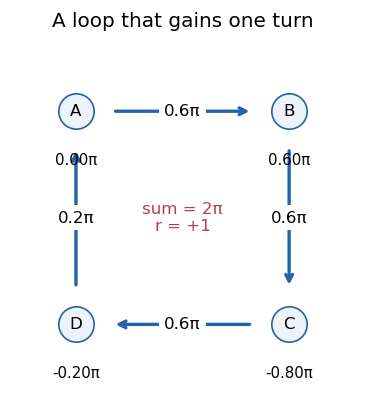

In [2]:
w = np.pi * np.array([[0.0, 0.6], [-0.2, -0.8]])
gx, gy = gradients(w)
steps = np.array([gx[0,0], gy[0,1], -gx[1,0], -gy[0,0]])
assert np.allclose(steps / np.pi, [.6, .6, .6, .2])
assert phase_residues(w)[0,0] == 1
table(['Clockwise edge', 'Raw difference / π', 'Wrapped step / π'],
      [(name, f'{raw:.1f}', f'{step:.1f}') for name, raw, step in
       zip(['A → B','B → C','C → D','D → A'], [.6,-1.4,.6,.2], steps/np.pi)])

xy = np.array([[0,1], [1,1], [0,0], [1,0]])  # flattened array order A,B,D,C
names = ['A','B','D','C']
def square(ax, values, title, edges=None, labels=None):
    edges = [(0,1),(1,3),(3,2),(2,0)] if edges is None else edges
    for i,(a,b) in enumerate(edges):
        p,q = xy[a],xy[b]
        ax.annotate('', xy=q*.83+p*.17, xytext=p*.83+q*.17,
                    arrowprops=dict(arrowstyle='->', color=BLUE, lw=2))
        if labels is not None:
            mid=(p+q)/2
            ax.text(*mid, labels[i], ha='center', va='center',
                    bbox=dict(facecolor='white', edgecolor='none', pad=3))
    for i,p in enumerate(xy):
        ax.scatter(*p, s=450, color='#edf3fa', edgecolor=BLUE, zorder=3)
        ax.text(p[0],p[1],names[i],ha='center',va='center',zorder=4)
        ax.text(p[0],p[1]-.25,f'{values.ravel()[i]/np.pi:.2f}π',ha='center',fontsize=9)
    ax.set(xlim=(-.3,1.3),ylim=(-.35,1.35),aspect='equal',title=title)
    ax.axis('off')
fig,ax=plt.subplots(figsize=(5,4))
square(ax,w,'A loop that gains one turn',labels=['0.6π','0.6π','0.6π','0.2π'])
ax.text(.5,.5,'sum = 2π\nr = +1',ha='center',va='center',color=RED)
plt.show()

## 2 · Reliability: which edge should we trust first?

Parvaneh uses an axial-neighbor score. With unit confidence,

$$S_p=\sum_{q\in N(p)}|W(w_q-w_p)|,\qquad R_p=\frac{1}{1+S_p}.$$

For $A$, $S_A=0.6\pi+0.2\pi=0.8\pi$, so $R_A\approx0.285$.
For $B$, $S_B=1.2\pi$, so $R_B\approx0.210$. Rate an edge using its
less reliable endpoint: $P_{ab}=\min(R_a,R_b)$.

This score is a heuristic, not a probability of correctness. A steep but correct
fringe may receive a low score. With supplied pixel confidence $c$, each term
in $S_p$ is multiplied by $\min(c_p,c_q)$; this is the implementation's specific
rating, not a claim that all published reliability algorithms use this formula.

In [3]:
rating=pixel_reliability(w)
table(['Pixel','Neighbor-step sum','Reliability'],
      [(names[i],f'{(1/r-1)/np.pi:.2f}π',f'{r:.4f}')
       for i,r in enumerate(rating.ravel())])
assert np.isclose(rating[0,0],1/(1+.8*np.pi))

| Pixel | Neighbor-step sum | Reliability |
|---|---|---|
| A | 0.80π | 0.2846 |
| B | 1.20π | 0.2096 |
| D | 0.80π | 0.2846 |
| C | 1.20π | 0.2096 |

## 3 · Grow the tree, then integrate

Start with four separate components. Sort the edges by decreasing priority.
Accept an edge only if its endpoints belong to different components; otherwise
it would close a loop. Stop merging once the image is connected.

For each accepted edge impose $u_b-u_a=g_{ab}$. Equivalently, writing
$u_p=w_p+2\pi n_p$ gives

$$n_b-n_a=\frac{g_{ab}-(w_b-w_a)}{2\pi},$$

an integer. Joining two existing components shifts one component by whole turns
so their connecting edge agrees. Parvaneh stores these shifts in a union–find
structure; below we use a short tree traversal so the arithmetic stays visible.
The edge enumeration and stable tie ordering follow the Python implementation.

| Visit | Edge | Priority | Decision |
|---|---|---|---|
| 1 | A–D | 0.2846 | merge |
| 2 | B–C | 0.2096 | merge |
| 3 | A–B | 0.2096 | merge |
| 4 | D–C | 0.2096 | skip: closes a loop |

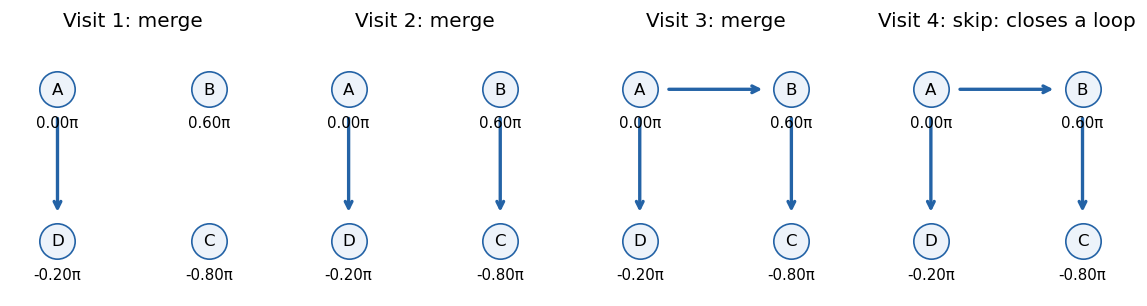

| Pixel | Measured / π | Tree result / π | Integer turns added |
|---|---|---|---|
| A | 0.0 | 0.0 | 0 |
| B | 0.6 | 0.6 | 0 |
| D | -0.2 | -0.2 | 0 |
| C | -0.8 | 1.2 | 1 |

In [4]:
# Axis 0 edges first, then axis 1 edges, exactly as in reliability_unwrap.
edges=[(0,2),(1,3),(0,1),(2,3)]
priority=np.array([min(rating.ravel()[a],rating.ravel()[b]) for a,b in edges])
order=np.argsort(-priority,kind='stable')
parent=list(range(4))
def root(a):
    while parent[a]!=a: a=parent[a]
    return a
accepted=[]; trace=[]; snapshots=[]
for rank,e in enumerate(order,1):
    a,b=edges[e]; ra,rb=root(a),root(b)
    take=ra!=rb
    if take:
        parent[rb]=ra; accepted.append((a,b))
    trace.append([rank,names[a]+'–'+names[b],f'{priority[e]:.4f}',
                  'merge' if take else 'skip: closes a loop'])
    snapshots.append(accepted.copy())
table(['Visit','Edge','Priority','Decision'],trace)
fig,axes=plt.subplots(1,4,figsize=(12,3))
for ax,tree,row in zip(axes,snapshots,trace):
    square(ax,w,f'Visit {row[0]}: {row[3]}',edges=tree)
plt.show()

u=np.full(4,np.nan); u[0]=w.ravel()[0]
queue=[0]
while queue:
    a=queue.pop(0)
    for i,j in accepted:
        b=j if i==a else i if j==a else None
        if b is not None and np.isnan(u[b]):
            u[b]=u[a]+wrap(w.ravel()[b]-w.ravel()[a]); queue.append(b)
tree_result=u.reshape(w.shape)
library_tree, tree_info=reliability_unwrap(w,return_info=True)
assert np.allclose(tree_result-tree_result[0,0],library_tree-library_tree[0,0])
assert tree_info.merges == tree_info.pixels-tree_info.components == 3
table(['Pixel','Measured / π','Tree result / π','Integer turns added'],
      [(names[i],f'{w.ravel()[i]/np.pi:.1f}',f'{u[i]/np.pi:.1f}',
        int(round((u[i]-w.ravel()[i])/(2*np.pi)))) for i in range(4)])

### What did skipping an edge achieve?

A tree has exactly one path between each pair of pixels, so it can always be
integrated. It does **not** satisfy every original edge: here the omitted edge
carries the loop disagreement. On residue-free data an omitted edge can agree
perfectly. `discarded` counts loop-closing edges, not detected errors.

The algorithm maximizes the sum of the chosen edge priorities (a maximum
spanning tree). It does not minimize reconstruction error against unknown truth,
nor does it minimize the flow objective introduced next.

## 4 · Flow: pay for integer corrections instead

Keep all edges, but allow a corrected step $h_e=g_e+2\pi k_e$ with integer
$k_e$. Let $s_{Ce}=+1$ when cell $C$ traverses an edge in its stored direction
and $-1$ otherwise. Closure requires

$$\sum_{e\in C}s_{Ce}h_e=0
\quad\Longleftrightarrow\quad
\sum_{e\in C}s_{Ce}k_e=-r_C.$$

For our clockwise loop $r=+1$. Subtracting one turn from **any one** of its
four clockwise steps restores closure. There are four choices. With positive
prices $c_e$, the linear objective is

$$\min_{k\in\mathbb Z^E}\sum_e c_e|k_e|.$$

On this single cell, one correction on the cheapest edge is optimal: a feasible
solution needs at least one turn, and additional positive-cost turns cannot help.
This is a tiny optimization problem we can enumerate before calling a solver.

| Edge corrected | Corrected clockwise steps / π | Cost |
|---|---|---|
| A→B | -1.4, 0.6, 0.6, 0.2 | 4.0 |
| B→C | 0.6, -1.4, 0.6, 0.2 | 1.0 |
| C→D | 0.6, 0.6, -1.4, 0.2 | 3.0 |
| D→A | 0.6, 0.6, 0.6, -1.8 | 2.0 |

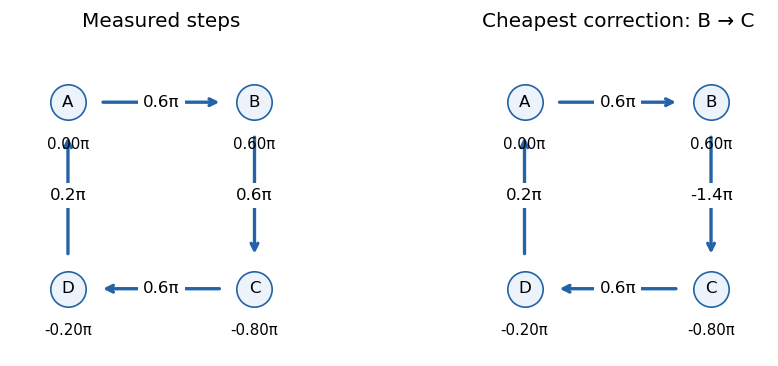

In [5]:
prices=np.array([4.,1.,3.,2.])  # illustrative clockwise edge prices
options=[]
for e in range(4):
    k=np.zeros(4,dtype=int); k[e]=-1
    corrected=steps+2*np.pi*k
    assert np.isclose(corrected.sum(),0)
    options.append([['A→B','B→C','C→D','D→A'][e],
                    ', '.join(f'{v:.1f}' for v in corrected/np.pi),prices[e]])
table(['Edge corrected','Corrected clockwise steps / π','Cost'],options)
best=int(np.argmin(prices))
fig,axes=plt.subplots(1,2,figsize=(9,3.5))
square(axes[0],w,'Measured steps',labels=[f'{v:.1f}π' for v in steps/np.pi])
fixed=steps.copy(); fixed[best]-=2*np.pi
square(axes[1],w,'Cheapest correction: B → C',labels=[f'{v:.1f}π' for v in fixed/np.pi])
plt.show()

## 5 · Why cells become network nodes

Two adjacent cells traverse their shared pixel edge in opposite directions.
Adding one turn to that edge changes their charges oppositely: a correction
can therefore be represented as flow between the **cell centers**. This is the
dual network. A route through several cells transfers a unit of charge from
one end of the route to the other, leaving intermediate cells balanced.

Boundary edges connect to an extra exterior node, often called ground. A net
charge can be balanced through this node; opposite residues need not always be
paired inside the image. “Ground” here is a network node, not a known phase value.

The next diagram is the geometry, not a computed optimal route. Dashed orange
links connect cell centers across pixel edges. The purple link reaches outside.

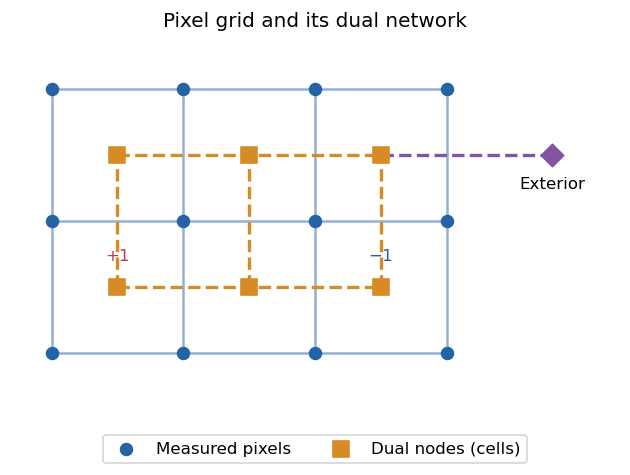

In [6]:
fig,ax=plt.subplots(figsize=(7,4))
for y0 in range(3): ax.plot([0,3],[y0,y0],color=BLUE,alpha=.5)
for x0 in range(4): ax.plot([x0,x0],[0,2],color=BLUE,alpha=.5)
xx,yy=np.meshgrid(np.arange(4),np.arange(3))
ax.scatter(xx,yy,color=BLUE,s=50,label='Measured pixels',zorder=3)
for y0 in [.5,1.5]:
    ax.plot([.5,2.5],[y0,y0],'--',color=ORANGE,lw=2)
for x0 in [.5,1.5,2.5]:
    ax.plot([x0,x0],[.5,1.5],'--',color=ORANGE,lw=2)
cx,cy=np.meshgrid([.5,1.5,2.5],[.5,1.5])
ax.scatter(cx,cy,marker='s',s=90,color=ORANGE,label='Dual nodes (cells)',zorder=4)
ax.plot([2.5,3.8],[1.5,1.5],'--',color='#8054a1',lw=2)
ax.scatter([3.8],[1.5],marker='D',s=90,color='#8054a1')
ax.text(3.8,1.25,'Exterior',ha='center')
ax.text(.5,.7,'+1',ha='center',color=RED)
ax.text(2.5,.7,'−1',ha='center',color=BLUE)
ax.set(aspect='equal',xlim=(-.3,4.3),ylim=(-.35,2.4),title='Pixel grid and its dual network')
ax.legend(loc='lower center',bbox_to_anchor=(.5,-.2),ncol=2); ax.axis('off')
plt.show()

### How the flow solve proceeds

1. Compute each cell's integer residue and the exterior balancing charge.
2. Create arcs across pixel edges, with prices for integer corrections.
3. Find a cheapest residual-network path from available supply to demand.
4. Send flow along it; reverse arcs allow earlier routing decisions to be undone.
5. Repeat until all charges balance, then integrate the corrected pixel steps.

For the 2-D linear-cost network with integral charges, network optimization has
an integral optimum. That is an optimum for the stated correction cost, not a
guarantee of recovering the physical truth. Tied costs can produce different
equally optimal surfaces. Masks need additional care: removing cell constraints
does not automatically enforce closure around a hole.

`network_flow_unwrap` takes **pixel** confidence rather than arbitrary edge
prices. It clips confidence to [0,1], scales by 1000, rounds to integer costs,
and uses the minimum endpoint cost. Positive confidence is given a minimum cost
of 1; zero confidence excludes pixels. Thus our four independent illustrative
prices above are a teaching model, not an API argument.

In [7]:
flow_small,flow_info=network_flow_unwrap(w,return_info=True)
fx,fy=gradients(w)
kx=np.rint((np.diff(flow_small,axis=1)-fx)/(2*np.pi)).astype(int)
ky=np.rint((np.diff(flow_small,axis=0)-fy)/(2*np.pi)).astype(int)
assert np.allclose(curl(fx+2*np.pi*kx,fy+2*np.pi*ky),0)
assert np.allclose(wrap(flow_small-w),0)
assert flow_info.total_cost==1000  # unit confidence, exactly one turn
print(flow_info)
print('Right-edge corrections (turns):\n',kx)
print('Down-edge corrections (turns):\n',ky)

NetworkFlowInfo(backend='python', cost='linear', pixels=4, nodes=2, edges=4, residues=1, augmentations=1, components=1, max_jump=1, ground_imbalance=1, total_cost=1000)
Right-edge corrections (turns):
 [[0]
 [0]]
Down-edge corrections (turns):
 [[1 0]]


## 6 · A surface with known truth and a noisy patch

We now generate a smooth surface whose neighbor steps are below $\pi$, add
seeded noise, and wrap it. The central patch has larger noise and lower supplied
confidence. This confidence comes from the noise model, not from inspecting the
answer. We run a reliability tree, uniform-cost flow, and confidence-cost flow.

An unwrapping method cannot remove measurement noise simply by restoring turns.
We therefore report both aligned RMSE against clean truth and integer-cycle
errors against the generated noisy phase. The latter is an answer key available
only in this synthetic experiment.

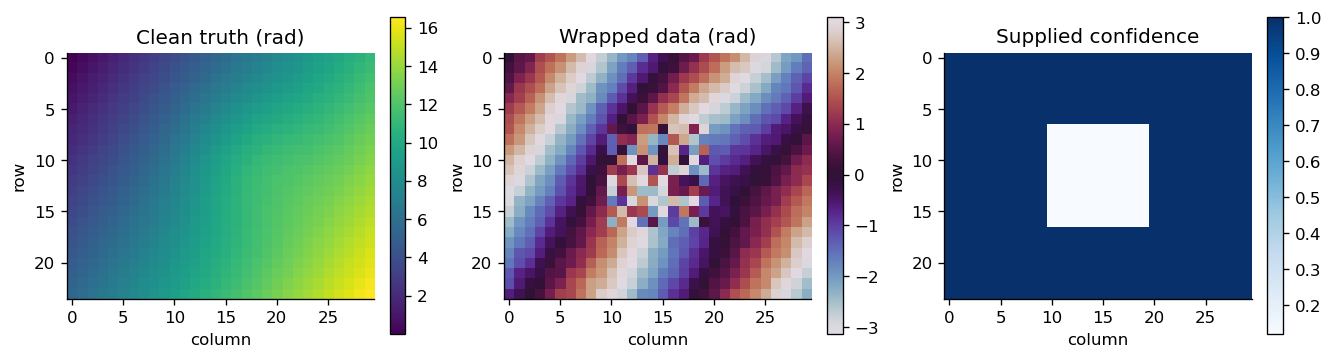

26 nonzero cell residues; patch noise σ = 1.6 rad.


In [8]:
rng=np.random.default_rng(21)
y,x=np.mgrid[0:24,0:30]
truth=.38*x+.24*y+1.8*np.exp(-((x-17)**2+(y-10)**2)/45)
patch=(x>=10)&(x<=19)&(y>=7)&(y<=16)
sigma=np.where(patch,1.6,.08)
noisy_truth=truth+rng.normal(size=truth.shape)*sigma
phase=wrap(noisy_truth)
confidence=np.where(patch,.12,1.)
charges=phase_residues(phase)
assert np.count_nonzero(charges)>0
results={}
results['Reliability'],ri=reliability_unwrap(phase,return_info=True)
results['Uniform flow'],fi=network_flow_unwrap(phase,return_info=True)
results['Confidence flow'],wi=network_flow_unwrap(phase,weight=confidence,return_info=True)
fig,axes=plt.subplots(1,3,figsize=(11,3.6),constrained_layout=True)
for ax,a,title,cmap in zip(axes,[truth,phase,confidence],
                          ['Clean truth (rad)','Wrapped data (rad)','Supplied confidence'],
                          ['viridis','twilight','Blues']):
    im=ax.imshow(a,cmap=cmap); ax.set_title(title); ax.set(xlabel='column',ylabel='row')
    fig.colorbar(im,ax=ax,shrink=.75)
plt.show()
print(f'{np.count_nonzero(charges)} nonzero cell residues; patch noise σ = 1.6 rad.')

### See where the algorithms place the corrections

Recover each output's integer edge correction from
$k_e=\mathrm{round}((u_b-u_a-g_e)/(2\pi))$.
Below, blue grid lines carry no correction, red segments mark nonzero corrected
edges, and signed circles mark measured cell residues. A marked edge is a place
where the output disagrees with the original shortest wrapped step; it is not
automatically a physical fault or a reconstruction error.

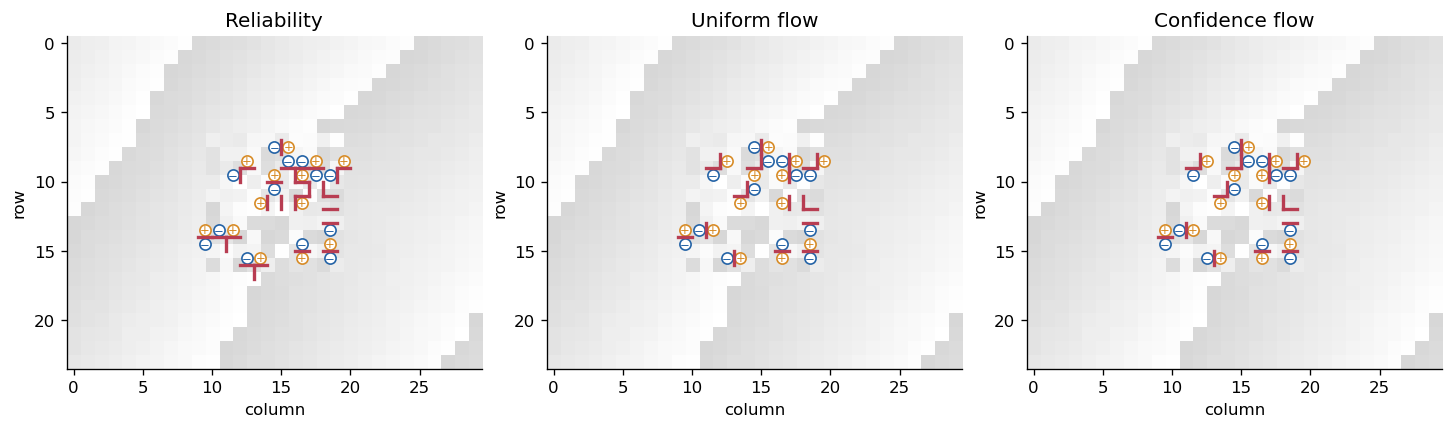

In [9]:
gx,gy=gradients(phase)
fig,axes=plt.subplots(1,3,figsize=(12,4),constrained_layout=True)
for ax,(name,u) in zip(axes,results.items()):
    kx=np.rint((np.diff(u,axis=1)-gx)/(2*np.pi)).astype(int)
    ky=np.rint((np.diff(u,axis=0)-gy)/(2*np.pi)).astype(int)
    assert np.allclose(wrap(u-phase),0,atol=1e-10)
    assert np.allclose(curl(gx+2*np.pi*kx,gy+2*np.pi*ky),0,atol=1e-10)
    ax.imshow(phase,cmap='gray',alpha=.16)
    for rr,cc in np.argwhere(kx!=0): ax.plot([cc,cc+1],[rr,rr],color=RED,lw=2)
    for rr,cc in np.argwhere(ky!=0): ax.plot([cc,cc],[rr,rr+1],color=RED,lw=2)
    for sign,color in [(1,ORANGE),(-1,BLUE)]:
        rr,cc=np.where(charges==sign)
        ax.scatter(cc+.5,rr+.5,s=45,facecolors='white',edgecolors=color)
        for r,c in zip(rr,cc): ax.text(c+.5,r+.5,'+' if sign>0 else '−',
                                      ha='center',va='center',fontsize=7,color=color)
    ax.set(title=name,xlabel='column',ylabel='row')
plt.show()

| Method | Aligned RMSE (rad) | Pixels with cycle errors | Max wrapping error |
|---|---|---|---|
| Reliability | 0.873 | 17 | 8.9e-16 |
| Uniform flow | 0.713 | 16 | 1.8e-15 |
| Confidence flow | 0.713 | 16 | 1.8e-15 |

Noisy-truth RMSE (noise benchmark): 0.595 rad
Tree: 719 merges, 667 loop-closing edges skipped.
Flow augmentations: uniform=13, confidence=13.


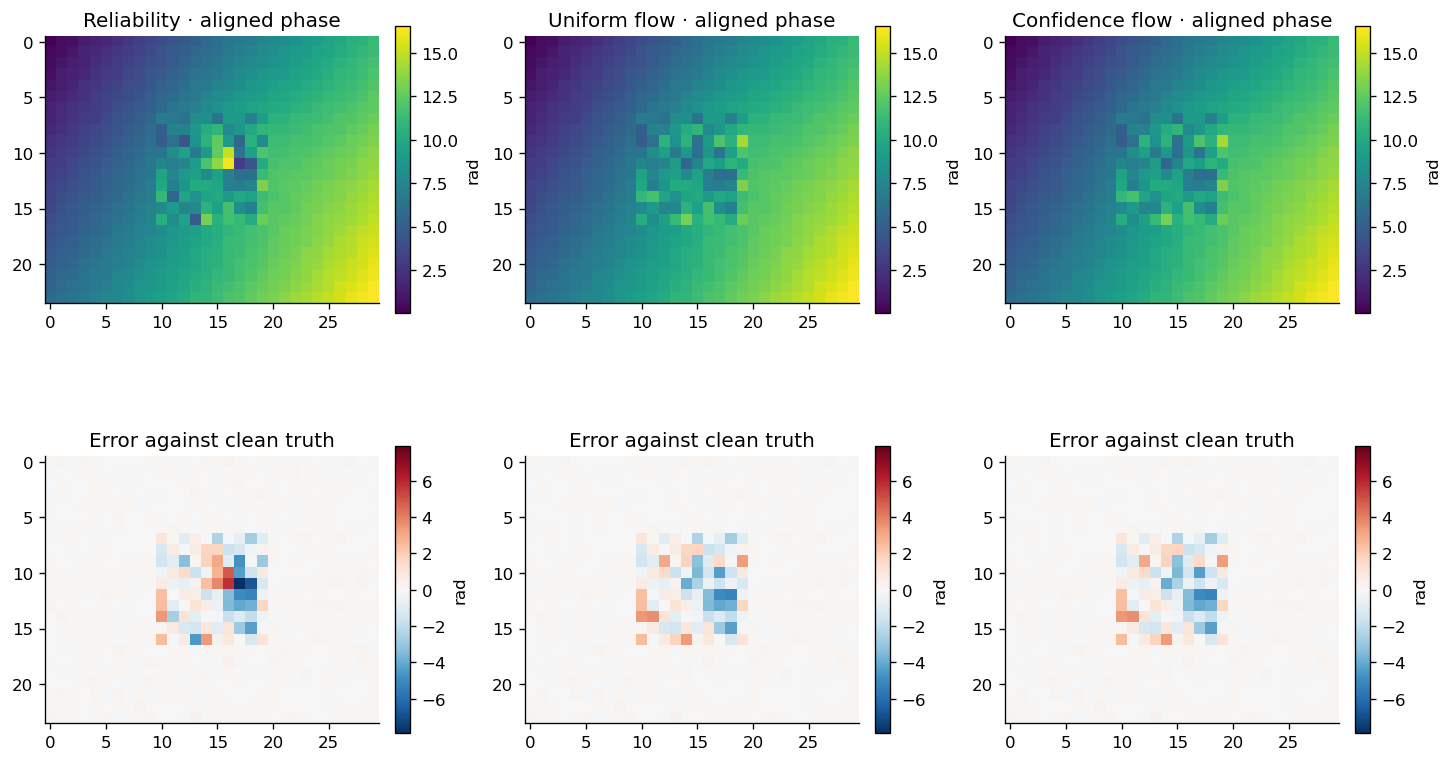

In [10]:
rows=[]; aligned={}; slips={}
for name,u in results.items():
    aligned[name]=u-np.mean(u-truth)
    n=np.rint((u-noisy_truth)/(2*np.pi)).astype(int)
    vals,counts=np.unique(n,return_counts=True)
    slips[name]=n-vals[np.argmax(counts)]  # remove one global integer offset
    rows.append([name,f'{rmse_aligned(u,truth):.3f}',
                 int(np.count_nonzero(slips[name])),
                 f'{np.max(np.abs(wrap(u-phase))):.1e}'])
table(['Method','Aligned RMSE (rad)','Pixels with cycle errors','Max wrapping error'],rows)
print(f'Noisy-truth RMSE (noise benchmark): {rmse_aligned(noisy_truth,truth):.3f} rad')
print(f'Tree: {ri.merges} merges, {ri.discarded} loop-closing edges skipped.')
print(f'Flow augmentations: uniform={fi.augmentations}, confidence={wi.augmentations}.')
fig,axes=plt.subplots(2,3,figsize=(12,7),constrained_layout=True)
limit=max(np.max(np.abs(a-truth)) for a in aligned.values())
for col,name in enumerate(results):
    im=axes[0,col].imshow(aligned[name],cmap='viridis',vmin=truth.min(),vmax=truth.max())
    axes[0,col].set_title(name+' · aligned phase')
    fig.colorbar(im,ax=axes[0,col],shrink=.7,label='rad')
    im=axes[1,col].imshow(aligned[name]-truth,cmap='RdBu_r',vmin=-limit,vmax=limit)
    axes[1,col].set_title('Error against clean truth')
    fig.colorbar(im,ax=axes[1,col],shrink=.7,label='rad')
plt.show()

## 7 · What to conclude, and what to try next

Read the measured table before choosing a winner. The tree obeys its selected
edges, while flow optimizes a correction cost. Neither objective includes the
unknown truth. Confidence can help route corrections through a noisy area, but
a mistaken confidence map can also make the result worse. All three outputs
retain the measured wrapped phase, including its noise.

For the default seed, uniform and confidence flow give the same errors: the
lower prices in this patch do not change the selected reconstruction. That is
a useful outcome rather than evidence that weighting is broken. Weighting only
changes the answer when it changes which feasible corrections are preferred.
The reliability result has 17 cycle-error pixels versus 16 for either flow
result here; this small experiment is an illustration, not a performance ranking.

| Question | Reliability sorting | Linear minimum-cost flow |
|---|---|---|
| What is selected? | A maximum-priority spanning forest | Integer edge corrections |
| Where are loops handled? | Loop-closing edges are skipped | Cell closure is enforced by conservation |
| What does confidence affect? | Local score and ordering | Price of adding a turn |
| Is truth recovery guaranteed? | No | No; optimality concerns the specified cost |
| Dimensions in this API? | Any number of axes | `network_flow_unwrap` requires 2-D |

In a connected region a tree uses $V-1$ edges; a forest with $C$ components uses
$V-C$. Each disconnected component has its own integer phase-offset ambiguity.
For gradient-fitting methods the additive offset is a continuous freedom;
wrap-preserving outputs restrict shifts to whole turns if absolute wrapped
values must stay fixed. Mean alignment here is only an evaluation convention.

The N-D reliability solver adds neighbors along every axis. The planar dual-flow
construction does not extend unchanged to a volume, where an edge can belong to
more than two cell faces. Parvaneh's separate `flow_nd_unwrap` offers other
strategies; its search limits and reports must be considered on larger volumes.

**Try these experiments:**

1. Set patch noise to 0.08. Predict the residue count and correction maps before
   rerunning. A residue-free example can still have discarded tree edges.
2. Raise patch confidence to 1.0. The two flow calls then solve the same problem.
3. Change the seed. Compare cycle errors as well as RMSE; avoid generalizing from
   one realization.
4. Set one patch confidence to zero only after reading the mask contract. It
   removes data rather than merely making a correction cheap.

### Implementation and further reading

This lesson follows the current [reliability implementation](../src/parvaneh/reliability.py)
and [2-D flow implementation](../src/parvaneh/network_flow.py). The former uses
the score explicitly derived above; it should not be confused with every detail
of the original Herráez algorithm. The repository's [mathematics](../docs/mathematics.md)
and [bibliography](../docs/references.md) give the broader derivations and
references, including Herráez et al. (2002) and Costantini (1998).